# 06 — Fine-tune Grade Model

End-to-end fine-tuning notebook for PSA grade prediction (1–10) on Pokémon cards.

**This notebook:** trains a `convnext_tiny` backbone end-to-end with front + back image fusion.  
**`05_feature_model.ipynb`:** frozen-feature / baseline comparison — kept separate.

Pipeline:
1. OpenCV card rectification
2. Albumentations augmentation
3. `timm` `convnext_tiny` backbone
4. Optional baseball-pretrained checkpoint loading
5. Grade head (10-class) + quality/confidence head
6. End-to-end fine-tuning
7. Robust evaluation — exact, ±1, MAE, confusion matrix, high-grade slice

## 1. Imports and Configuration

In [1]:
import os, json, math, random, time
from pathlib import Path
from datetime import datetime
from copy import deepcopy

import numpy as np
import pandas as pd
import cv2
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    mean_absolute_error
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.auto import tqdm

print(f'torch  {torch.__version__}')
print(f'timm   {timm.__version__}')
print(f'CUDA   {torch.cuda.is_available()}')

/Users/srinivasdoddi/srini/agentic-card-seller-os/backend/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch  2.12.0
timm   1.0.27
CUDA   False


In [2]:
# ── Reproducibility ───────────────────────────────────────────────
SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(SEED)

# ── Device — prefer MPS (Apple Silicon) > CUDA > CPU ─────────────
if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'

# ── Task ──────────────────────────────────────────────────────────
TARGET_MODE   = 'grade10'   # exact PSA 1-10 label space
NUM_CLASSES   = 10          # keep 10 for future extensibility
# NOTE: current dataset only has PSA 8/9/10. The model will learn to
# assign near-zero probability to grades 1-7. Add lower-grade data
# later and re-train without changing anything else.

# ── Images ────────────────────────────────────────────────────────
IMG_SIZE          = 224     # 384 is ideal but slow on CPU; 224 trains fine on MPS
USE_BACK_IMAGE    = True
USE_RECTIFICATION = True

# ── Training ─────────────────────────────────────────────────────
BATCH_SIZE          = 16
NUM_EPOCHS          = 20
LR                  = 3e-4
WEIGHT_DECAY        = 1e-4
GRAD_CLIP           = 1.0
EARLY_STOP_PATIENCE = 5
USE_MIXED_PRECISION = False  # AMP not supported on MPS; only used on CUDA
USE_CLASS_WEIGHTS   = True   # WeightedRandomSampler (dataset is balanced, low impact here)

# ── Model ─────────────────────────────────────────────────────────
BACKBONE_NAME            = 'convnext_tiny'
BASEBALL_PRETRAINED_CKPT = None   # e.g. Path('../backend/models/grade_mlp_best.pt')

# ── Data ──────────────────────────────────────────────────────────
DATA_DIR  = Path('../data')
TRAIN_CSV = DATA_DIR / 'pokemon_train.csv'
VAL_CSV   = DATA_DIR / 'pokemon_val.csv'
TEST_CSV  = DATA_DIR / 'pokemon_test.csv'

# ── Artifacts ─────────────────────────────────────────────────────
CHECKPOINT_DIR = Path('artifacts/finetune')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Class names for display
CLASS_NAMES = [f'PSA {g}' for g in range(1, 11)]

print(f'Device          : {DEVICE}')
print(f'Backbone        : {BACKBONE_NAME}')
print(f'Image size      : {IMG_SIZE}')
print(f'Batch size      : {BATCH_SIZE}')
print(f'Epochs          : {NUM_EPOCHS}')
print(f'Front+Back      : {USE_BACK_IMAGE}')
print(f'Rectification   : {USE_RECTIFICATION}')
print(f'Mixed precision : {USE_MIXED_PRECISION}')
print(f'Checkpoint dir  : {CHECKPOINT_DIR}')

Device          : mps
Backbone        : convnext_tiny
Image size      : 224
Batch size      : 16
Epochs          : 20
Front+Back      : True
Rectification   : True
Mixed precision : False
Checkpoint dir  : artifacts/finetune


## 2. Data Schema and Assumptions

Each split CSV must contain:

| Column | Type | Notes |
|---|---|---|
| `front_image_path` | str | Absolute or relative path to front JPEG/PNG |
| `back_image_path`  | str | Required if `USE_BACK_IMAGE=True` |
| `grade`            | int | PSA grade 1–10 |
| `grader`           | str | Optional — e.g. `PSA`, `BGS` |
| `capture_type`     | str | Optional — e.g. `raw`, `ebay_listing` |
| `card_id`          | str | Optional unique identifier |
| `source_dataset`   | str | Optional — e.g. `baseball_2024`, `pokemon_2025` |

Grade labels are converted to 0-indexed (`grade - 1`) for training and back to 1-indexed for all metrics.

In [3]:
REQUIRED_COLS = ['front_image_path', 'grade']
if USE_BACK_IMAGE:
    REQUIRED_COLS.append('back_image_path')

def validate_csv(path: Path, split: str = 'train') -> pd.DataFrame:
    """Load and validate a split CSV. Returns the DataFrame."""
    if not path.exists():
        print(f'  ⚠  {split} CSV not found: {path}')
        return pd.DataFrame()

    df = pd.read_csv(path)
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f'{split} CSV missing columns: {missing}')

    bad_grades = df[~df['grade'].between(1, 10)]
    if not bad_grades.empty:
        print(f'  ⚠  {split}: {len(bad_grades)} rows with grade outside 1-10 — dropped')
        df = df[df['grade'].between(1, 10)].reset_index(drop=True)

    print(f'  ✓ {split:5s}: {len(df):>5,} rows  |  grade dist: {dict(df["grade"].value_counts().sort_index())}')
    return df


print('Validating CSVs...')
train_df = validate_csv(TRAIN_CSV, 'train')
val_df   = validate_csv(VAL_CSV,   'val')
test_df  = validate_csv(TEST_CSV,  'test')

if train_df.empty:
    print('\n  No training data found — cells below will define helpers but skip training.')
    print('  Populate data/pokemon_train.csv (and val/test) then re-run.')

Validating CSVs...
  ✓ train:    69 rows  |  grade dist: {8: np.int64(23), 9: np.int64(23), 10: np.int64(23)}
  ✓ val  :    15 rows  |  grade dist: {8: np.int64(5), 9: np.int64(5), 10: np.int64(5)}
  ✓ test :     9 rows  |  grade dist: {8: np.int64(3), 9: np.int64(3), 10: np.int64(3)}


In [4]:
train_df[0:4]

,front_image_path,back_image_path,grade,grader,source_dataset,card_id
0,/Users/srinivasdoddi/srini/agentic-card-seller...,/Users/srinivasdoddi/srini/agentic-card-seller...,8,PSA,pokemon_ebay,psa8_card19
1,/Users/srinivasdoddi/srini/agentic-card-seller...,/Users/srinivasdoddi/srini/agentic-card-seller...,8,PSA,pokemon_ebay,psa8_card10
2,/Users/srinivasdoddi/srini/agentic-card-seller...,/Users/srinivasdoddi/srini/agentic-card-seller...,8,PSA,pokemon_ebay,psa8_card23
3,/Users/srinivasdoddi/srini/agentic-card-seller...,/Users/srinivasdoddi/srini/agentic-card-seller...,8,PSA,pokemon_ebay,psa8_card5


## 3. Card Rectification Utilities

Perspective-correct each card image using the largest detected contour.  
Falls back to the raw image if detection fails — never errors out.

In [5]:
def order_points(pts: np.ndarray) -> np.ndarray:
    """Order four points as [top-left, top-right, bottom-right, bottom-left]."""
    rect = np.zeros((4, 2), dtype='float32')
    s    = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left: smallest sum
    rect[2] = pts[np.argmax(s)]   # bottom-right: largest sum
    diff    = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right: smallest diff
    rect[3] = pts[np.argmax(diff)]  # bottom-left: largest diff
    return rect


def four_point_transform(image: np.ndarray, pts: np.ndarray) -> np.ndarray:
    """Apply perspective transform given four corner points."""
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    width_a  = np.linalg.norm(br - bl)
    width_b  = np.linalg.norm(tr - tl)
    max_w    = max(int(width_a), int(width_b))

    height_a = np.linalg.norm(tr - br)
    height_b = np.linalg.norm(tl - bl)
    max_h    = max(int(height_a), int(height_b))

    if max_w < 10 or max_h < 10:
        return image  # degenerate contour

    dst = np.array([
        [0,         0        ],
        [max_w - 1, 0        ],
        [max_w - 1, max_h - 1],
        [0,         max_h - 1],
    ], dtype='float32')

    M = cv2.getPerspectiveTransform(rect, dst)
    return cv2.warpPerspective(image, M, (max_w, max_h))


def rectify_card(img: np.ndarray) -> np.ndarray:
    """
    Detect the card's rectangular border and perspective-correct it.
    Returns the warped image, or the original if detection fails.
    """
    gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur   = cv2.GaussianBlur(gray, (5, 5), 0)
    edged  = cv2.Canny(blur, 30, 120)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    dilated = cv2.dilate(edged, kernel, iterations=2)

    cnts, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return img

    # Largest contour by area
    cnts = sorted(cnts, key=cv2.contourArea, reverse=True)
    h, w = img.shape[:2]
    min_area = 0.1 * h * w

    for c in cnts[:5]:
        if cv2.contourArea(c) < min_area:
            break
        peri   = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:
            pts = approx.reshape(4, 2).astype('float32')
            return four_point_transform(img, pts)

    return img   # fallback: no clean quadrilateral found


def safe_load_and_rectify(path: str | Path, rectify: bool = True) -> np.ndarray | None:
    """
    Load an image from disk and optionally perspective-correct it.
    Returns an RGB ndarray, or None if the file is unreadable.
    """
    try:
        img = cv2.imread(str(path))
        if img is None:
            return None
        if rectify:
            img = rectify_card(img)
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    except Exception:
        return None


print('Rectification utilities defined ✓')

Rectification utilities defined ✓


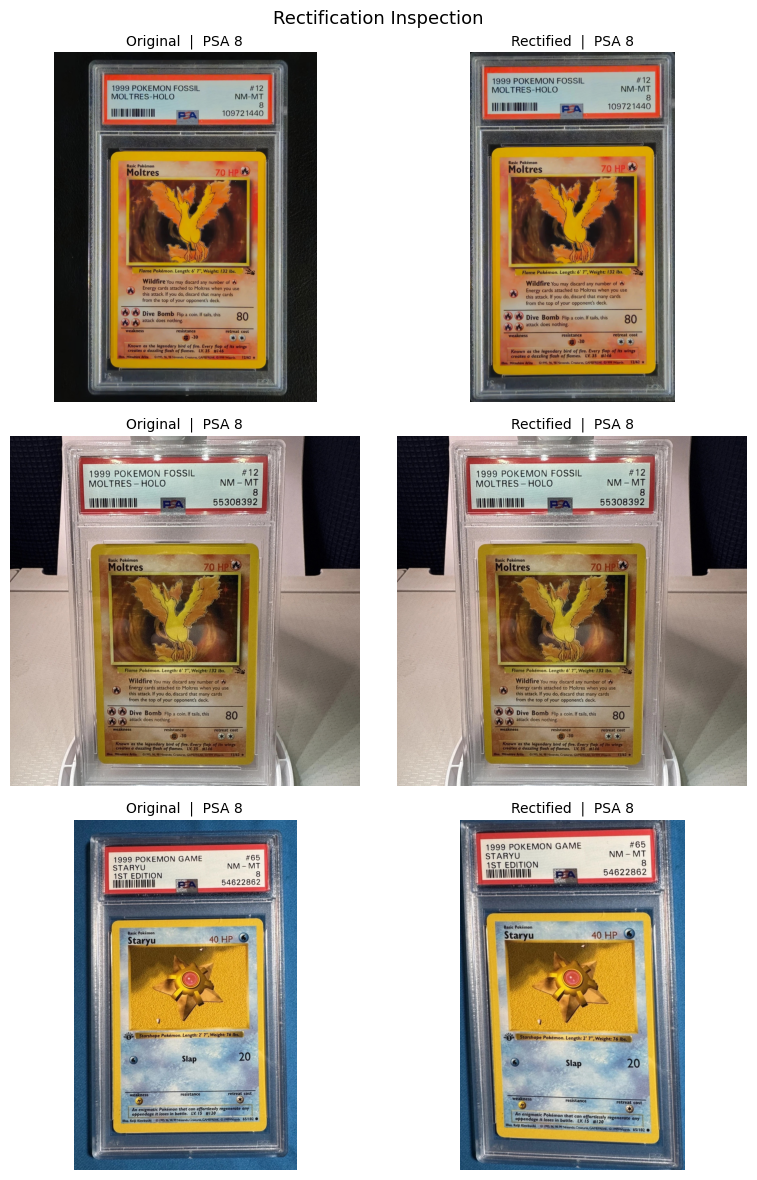

In [6]:
# ── Inspect rectification on a few training examples ─────────────
N_INSPECT = 3

if not train_df.empty:
    sample = train_df.head(N_INSPECT)
    fig, axes = plt.subplots(N_INSPECT, 2, figsize=(8, N_INSPECT * 4))
    if N_INSPECT == 1:
        axes = [axes]

    for i, (_, row) in enumerate(sample.iterrows()):
        original = safe_load_and_rectify(row['front_image_path'], rectify=False)
        rectified = safe_load_and_rectify(row['front_image_path'], rectify=True)

        for j, (ax, img, title) in enumerate(zip(
            axes[i], [original, rectified], ['Original', 'Rectified']
        )):
            if img is not None:
                ax.imshow(img)
            else:
                ax.text(0.5, 0.5, 'Load failed', ha='center', va='center',
                        transform=ax.transAxes, color='gray')
            ax.axis('off')
            ax.set_title(f'{title}  |  PSA {row["grade"]}', fontsize=10)

    plt.suptitle('Rectification Inspection', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No training data — skipping rectification inspection.')

## 4. Albumentations Transforms

**Train:** mild brightness, contrast, blur, JPEG noise, slight affine.  
**Eval:** resize + normalize only.  
No heavy augmentations that destroy card defects (no flips, no heavy crops).

In [7]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    # Mild colour / lighting
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.6),
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=15, val_shift_limit=10, p=0.4),

    # Mild blur / noise (simulates scan quality variation)
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MotionBlur(blur_limit=5, p=1.0),
    ], p=0.3),
    A.ImageCompression(quality_lower=75, quality_upper=100, p=0.3),
    A.GaussNoise(var_limit=(5, 20), p=0.2),

    # Slight geometry (handles angled eBay photos)
    A.ShiftScaleRotate(
        shift_limit=0.02, scale_limit=0.05, rotate_limit=3,
        border_mode=cv2.BORDER_REFLECT_101, p=0.4
    ),
    A.Perspective(scale=(0.02, 0.05), p=0.2),

    # Normalize + tensor
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

print('Transforms defined ✓')
print(f'  train : {len(train_transform.transforms)} stages')
print(f'  eval  : {len(eval_transform.transforms)} stages')

Transforms defined ✓
  train : 10 stages
  eval  : 3 stages


/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_43659/1247414828.py:16: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, quality_upper=100, p=0.3),
/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_43659/1247414828.py:17: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 20), p=0.2),
/Users/srinivasdoddi/srini/agentic-card-seller-os/backend/venv/lib/python3.14/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 5. Dataset Class

In [8]:
class CardGradeDataset(Dataset):
    """
    Loads front (+ optional back) card images and PSA grade labels.

    Returns a dict:
        front       : FloatTensor (C, H, W)
        back        : FloatTensor (C, H, W)  — zeros if USE_BACK_IMAGE=False or path missing
        label       : LongTensor scalar       — grade 0-indexed (0=PSA1 … 9=PSA10)
        grade       : int                     — raw PSA grade 1-10
        card_id     : str                     — optional identifier
    """

    def __init__(
        self,
        df:        pd.DataFrame,
        transform: A.Compose,
        use_back:  bool = USE_BACK_IMAGE,
        rectify:   bool = USE_RECTIFICATION,
    ):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.use_back  = use_back
        self.rectify   = rectify
        self._blank    = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    def __len__(self):
        return len(self.df)

    def _load(self, path: str | None) -> np.ndarray:
        """Load and optionally rectify; fall back to blank on failure."""
        if not path or not Path(str(path)).exists():
            return self._blank.copy()
        img = safe_load_and_rectify(path, rectify=self.rectify)
        if img is None:
            return self._blank.copy()
        return img  # already RGB ndarray

    def __getitem__(self, idx: int) -> dict:
        row   = self.df.iloc[idx]
        grade = int(row['grade'])                   # 1–10
        label = grade - 1                           # 0–9 for CE loss

        front_img = self._load(row.get('front_image_path'))
        front_t   = self.transform(image=front_img)['image']

        if self.use_back and 'back_image_path' in row:
            back_img = self._load(row.get('back_image_path'))
            back_t   = self.transform(image=back_img)['image']
        else:
            back_t = torch.zeros_like(front_t)

        return {
            'front':   front_t,
            'back':    back_t,
            'label':   torch.tensor(label, dtype=torch.long),
            'grade':   grade,
            'card_id': str(row.get('card_id', '')),
        }


def make_weighted_sampler(df: pd.DataFrame) -> WeightedRandomSampler:
    """Inverse-frequency sampler so rare grades get equal representation."""
    counts = df['grade'].value_counts().sort_index()
    freq   = df['grade'].map(lambda g: counts[g])
    weights = 1.0 / freq.values
    return WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True,
    )


print('CardGradeDataset defined ✓')

CardGradeDataset defined ✓


## 6. Model Architecture

One shared `convnext_tiny` backbone encodes front and back images.  
Embeddings are concatenated → **grade head** (10-class softmax) + **quality head** (scalar confidence).  

The quality head can be trained with explicit labels later (e.g. image quality score).  
For now it is kept in the graph but its loss is only used if `quality_labels` are provided.

In [9]:
class GradeNet(nn.Module):
    """
    Dual-stream (front + back) card grading model.

    Architecture:
        front ──┐
                ├── concat ── dropout ── grade_head  (10 logits)
        back  ──┘         └──────────── quality_head (1 logit)

    If use_back=False the back stream is zeroed out at forward time.
    """

    def __init__(
        self,
        backbone_name: str  = BACKBONE_NAME,
        use_back:      bool = USE_BACK_IMAGE,
        num_classes:   int  = NUM_CLASSES,
        pretrained:    bool = True,
        drop_rate:     float = 0.3,
    ):
        super().__init__()
        self.use_back = use_back

        # Shared backbone — load ImageNet weights unless we'll overwrite with baseball ckpt
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,      # remove classifier head
            global_pool='avg',  # pooled (B, C) features
        )
        feat_dim = self.backbone.num_features

        # Fusion dim: 2× if using back, else 1×
        fused_dim = feat_dim * 2 if use_back else feat_dim

        self.dropout     = nn.Dropout(drop_rate)
        self.grade_head  = nn.Linear(fused_dim, num_classes)
        self.quality_head = nn.Linear(fused_dim, 1)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone(x)   # (B, feat_dim)

    def forward(
        self,
        front: torch.Tensor,
        back:  torch.Tensor | None = None,
    ) -> dict[str, torch.Tensor]:
        f_feat = self.encode(front)

        if self.use_back and back is not None:
            b_feat = self.encode(back)
            fused  = torch.cat([f_feat, b_feat], dim=1)
        else:
            fused  = f_feat

        fused = self.dropout(fused)
        return {
            'grade_logits':  self.grade_head(fused),     # (B, 10)
            'quality_logit': self.quality_head(fused),   # (B, 1)
        }


def count_params(model: nn.Module) -> str:
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return f'{total/1e6:.1f}M total, {train/1e6:.1f}M trainable'


print('GradeNet defined ✓')
# Quick shape check
_m = GradeNet(pretrained=False)
_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
_out = _m(_x, _x)
print(f'  grade_logits  shape : {_out["grade_logits"].shape}')
print(f'  quality_logit shape : {_out["quality_logit"].shape}')
print(f'  Parameters          : {count_params(_m)}')
del _m, _x, _out

GradeNet defined ✓
  grade_logits  shape : torch.Size([2, 10])
  quality_logit shape : torch.Size([2, 1])
  Parameters          : 27.8M total, 27.8M trainable


## 7. Optional Pretrained Checkpoint Loading

If `BASEBALL_PRETRAINED_CKPT` points to a file, the matching backbone weights are loaded.  
Mismatched keys (e.g. grade head dimension mismatch) are skipped gracefully.

In [10]:
def load_backbone_checkpoint(model: GradeNet, ckpt_path: str | Path) -> GradeNet:
    """
    Load matching weights from a pretrained checkpoint into model.backbone.
    Skips missing / shape-mismatched keys. Prints a summary.
    """
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        print(f'  ⚠  Checkpoint not found: {ckpt_path} — using ImageNet init')
        return model

    payload = torch.load(ckpt_path, map_location='cpu')

    # Accept bare state_dict or dict with 'model_state_dict' / 'state_dict' key
    if isinstance(payload, dict):
        state = (
            payload.get('model_state_dict')
            or payload.get('state_dict')
            or payload
        )
    else:
        state = payload

    # Strip common prefixes
    def strip_prefix(d, prefix):
        return {k[len(prefix):]: v for k, v in d.items() if k.startswith(prefix)}

    for pfx in ('backbone.', 'model.backbone.', 'module.backbone.'):
        sub = strip_prefix(state, pfx)
        if sub:
            state = sub
            break

    current = model.backbone.state_dict()
    matched, skipped_shape, skipped_missing = [], [], []

    new_state = {}
    for k, v in state.items():
        if k not in current:
            skipped_missing.append(k)
        elif current[k].shape != v.shape:
            skipped_shape.append(k)
        else:
            new_state[k] = v
            matched.append(k)

    current.update(new_state)
    model.backbone.load_state_dict(current, strict=False)

    print(f'  Checkpoint : {ckpt_path.name}')
    print(f'  Matched    : {len(matched)} layers')
    print(f'  Skipped (shape mismatch): {len(skipped_shape)}')
    print(f'  Skipped (not in ckpt)   : {len(skipped_missing)}')
    return model


print('load_backbone_checkpoint defined ✓')

load_backbone_checkpoint defined ✓


## 8. Losses and Optimization

In [11]:
def build_optimizer_and_scheduler(
    model: nn.Module,
    num_steps: int,
):
    optimizer = optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_steps,
        eta_min=LR * 0.01,
    )
    return optimizer, scheduler


grade_criterion   = nn.CrossEntropyLoss()         # main task
quality_criterion = nn.BCEWithLogitsLoss()        # optional second head

print('Loss functions and optimizer builder defined ✓')

Loss functions and optimizer builder defined ✓


## 9. Training Loop

In [12]:
def train_one_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    optimizer: optim.Optimizer,
    scheduler,
    scaler:    GradScaler | None,
    epoch:     int,
) -> dict:
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc=f'Train E{epoch:02d}', leave=False)
    for batch in pbar:
        front  = batch['front'].to(DEVICE)
        back   = batch['back'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        optimizer.zero_grad()

        with autocast(enabled=USE_MIXED_PRECISION):
            out  = model(front, back)
            loss = grade_criterion(out['grade_logits'], labels)

        if scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

        scheduler.step()

        total_loss += loss.item() * len(labels)
        preds = out['grade_logits'].argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f'{loss.item():.3f}')

    return {
        'loss':     total_loss / len(loader.dataset),
        'preds':    np.array(all_preds),
        'labels':   np.array(all_labels),
    }


@torch.no_grad()
def evaluate_one_epoch(
    model:  nn.Module,
    loader: DataLoader,
    split:  str = 'val',
) -> dict:
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_grades = [], [], []
    all_confs = []

    pbar = tqdm(loader, desc=f'{split:4s} eval', leave=False)
    for batch in pbar:
        front  = batch['front'].to(DEVICE)
        back   = batch['back'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        with autocast(enabled=USE_MIXED_PRECISION):
            out  = model(front, back)
            loss = grade_criterion(out['grade_logits'], labels)

        total_loss += loss.item() * len(labels)
        probs = torch.softmax(out['grade_logits'], dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        confs = probs.max(axis=1)

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_grades.extend(batch['grade'])
        all_confs.extend(confs)

    return {
        'loss':   total_loss / len(loader.dataset),
        'preds':  np.array(all_preds),
        'labels': np.array(all_labels),
        'grades': np.array(all_grades),
        'confs':  np.array(all_confs),
    }


print('Training loop functions defined ✓')

Training loop functions defined ✓


## 10. Metrics

In [13]:
def compute_metrics(preds_0idx: np.ndarray, labels_0idx: np.ndarray) -> dict:
    """
    Compute grading metrics from 0-indexed predictions and labels.
    Returns 1-indexed grades for all reported values.
    """
    pred_grades = preds_0idx  + 1   # 1-10
    true_grades = labels_0idx + 1   # 1-10

    exact      = np.mean(pred_grades == true_grades)
    within1    = np.mean(np.abs(pred_grades - true_grades) <= 1)
    mae        = mean_absolute_error(true_grades, pred_grades)

    # High-grade slice: cards graded 8, 9, or 10
    hg_mask    = true_grades >= 8
    hg_exact   = np.mean(pred_grades[hg_mask] == true_grades[hg_mask]) if hg_mask.any() else float('nan')
    hg_within1 = np.mean(np.abs(pred_grades[hg_mask] - true_grades[hg_mask]) <= 1) if hg_mask.any() else float('nan')

    # Per-grade accuracy
    per_grade = {}
    for g in range(1, 11):
        mask = true_grades == g
        if mask.any():
            per_grade[g] = float(np.mean(pred_grades[mask] == g))

    return {
        'exact':        float(exact),
        'within1':      float(within1),
        'mae':          float(mae),
        'hg_exact':     float(hg_exact),
        'hg_within1':   float(hg_within1),
        'per_grade':    per_grade,
        'pred_grades':  pred_grades,
        'true_grades':  true_grades,
    }


def print_metrics(m: dict, prefix: str = ''):
    tag = f'[{prefix}] ' if prefix else ''
    print(f'  {tag}Exact {m["exact"]*100:5.1f}%  '
          f'±1 {m["within1"]*100:5.1f}%  '
          f'MAE {m["mae"]:4.2f}  '
          f'HG-exact {m["hg_exact"]*100:5.1f}%  '
          f'HG-±1 {m["hg_within1"]*100:5.1f}%')


def plot_confusion_matrix(m: dict, title: str = 'Confusion Matrix'):
    cm = confusion_matrix(m['true_grades'], m['pred_grades'], labels=list(range(1, 11)))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=[f'PSA {g}' for g in range(1, 11)],
        yticklabels=[f'PSA {g}' for g in range(1, 11)],
        ax=ax,
    )
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True',      fontsize=11)
    ax.set_title(title,        fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_error_distribution(m: dict, title: str = 'Prediction Error Distribution'):
    errors = m['pred_grades'] - m['true_grades']
    fig, ax = plt.subplots(figsize=(10, 4))
    bins = range(int(errors.min()) - 1, int(errors.max()) + 2)
    ax.hist(errors, bins=bins, color='#6366f1', edgecolor='white', rwidth=0.8)
    ax.axvline(0, color='#ef4444', linewidth=2, label='No error')
    ax.axvline(-1, color='#f59e0b', linewidth=1, linestyle='--', label='±1 boundary')
    ax.axvline(+1, color='#f59e0b', linewidth=1, linestyle='--')
    ax.set_xlabel('Prediction error (pred − true)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()


print('Metrics and plot helpers defined ✓')

Metrics and plot helpers defined ✓


## 11. Training Run

Instantiate datasets → model → train → evaluate val → evaluate test.  
Saves best checkpoint (by within-1 accuracy) and last checkpoint each epoch.

In [14]:
# ── Build datasets and loaders ────────────────────────────────────
# num_workers=0 required on macOS in Jupyter (multiprocessing limitation)
NUM_WORKERS = 0

def build_loaders(train_df, val_df, test_df):
    train_ds = CardGradeDataset(train_df, train_transform)
    val_ds   = CardGradeDataset(val_df,   eval_transform)
    test_ds  = CardGradeDataset(test_df,  eval_transform)

    sampler = make_weighted_sampler(train_df) if USE_CLASS_WEIGHTS else None
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        shuffle=(sampler is None),
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == 'cuda'),
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'),
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'),
    )
    print(f'Train : {len(train_ds):,} samples — {len(train_loader)} batches')
    print(f'Val   : {len(val_ds):,} samples')
    print(f'Test  : {len(test_ds):,} samples')
    return train_loader, val_loader, test_loader


if not train_df.empty:
    train_loader, val_loader, test_loader = build_loaders(train_df, val_df, test_df)
else:
    print('Skipping loader construction — no data.')
    train_loader = val_loader = test_loader = None

Train : 69 samples — 5 batches
Val   : 15 samples
Test  : 9 samples


In [15]:
# ── Instantiate model ─────────────────────────────────────────────

if train_loader is not None:
    model = GradeNet(pretrained=True).to(DEVICE)

    if BASEBALL_PRETRAINED_CKPT is not None:
        print('Loading baseball pretrained checkpoint...')
        model = load_backbone_checkpoint(model, BASEBALL_PRETRAINED_CKPT)

    num_steps = NUM_EPOCHS * len(train_loader)
    optimizer, scheduler = build_optimizer_and_scheduler(model, num_steps)
    scaler = GradScaler() if USE_MIXED_PRECISION else None

    print(f'\nModel  : {BACKBONE_NAME}')
    print(f'Params : {count_params(model)}')
    print(f'Steps  : {num_steps:,} ({NUM_EPOCHS} epochs × {len(train_loader)} batches)')
else:
    print('No data — skipping model instantiation.')
    model = None


Model  : convnext_tiny
Params : 27.8M total, 27.8M trainable
Steps  : 100 (20 epochs × 5 batches)


In [16]:
# ── Main training loop ────────────────────────────────────────────

history = {'train_loss': [], 'val_loss': [], 'val_exact': [], 'val_within1': [], 'val_mae': []}

best_within1   = -1.0
best_state     = None
no_improve     = 0

if model is not None and train_loader is not None:
    print(f'\n{"Epoch":>5}  {"Train Loss":>10}  {"Val Loss":>8}  '
          f'{"Exact":>7}  {"±1":>7}  {"MAE":>6}  {"HG-Exact":>9}  LR')
    print('─' * 80)

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()

        tr = train_one_epoch(model, train_loader, optimizer, scheduler, scaler, epoch)
        tr_m = compute_metrics(tr['preds'], tr['labels'])

        vl = evaluate_one_epoch(model, val_loader, split='val')
        vl_m = compute_metrics(vl['preds'], vl['labels'])

        dt = time.time() - t0
        lr_now = scheduler.get_last_lr()[0]

        print(
            f'{epoch:>5}  {tr["loss"]:>10.4f}  {vl["loss"]:>8.4f}  '
            f'{vl_m["exact"]*100:>6.1f}%  {vl_m["within1"]*100:>6.1f}%  '
            f'{vl_m["mae"]:>6.2f}  {vl_m["hg_exact"]*100:>8.1f}%  '
            f'{lr_now:.2e}  ({dt:.0f}s)'
        )

        history['train_loss'].append(tr['loss'])
        history['val_loss'].append(vl['loss'])
        history['val_exact'].append(vl_m['exact'])
        history['val_within1'].append(vl_m['within1'])
        history['val_mae'].append(vl_m['mae'])

        # ── Save best checkpoint ──────────────────────────────────
        if vl_m['within1'] > best_within1:
            best_within1 = vl_m['within1']
            best_state   = deepcopy(model.state_dict())
            no_improve   = 0
            torch.save(best_state, CHECKPOINT_DIR / 'grade_model_best.pt')
            print(f'         ↑ new best ±1={best_within1*100:.1f}% — saved')
        else:
            no_improve += 1

        # ── Save last checkpoint every epoch ─────────────────────
        torch.save(model.state_dict(), CHECKPOINT_DIR / 'grade_model_last.pt')

        # ── Early stopping ────────────────────────────────────────
        if no_improve >= EARLY_STOP_PATIENCE:
            print(f'\n  Early stop at epoch {epoch} (no improvement for {EARLY_STOP_PATIENCE} epochs)')
            break

    print('\nTraining complete.')

else:
    print('No model / data — skipping training loop.')


Epoch  Train Loss  Val Loss    Exact       ±1     MAE   HG-Exact  LR
────────────────────────────────────────────────────────────────────────────────


Train E01:   0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_43659/3619585571.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_MIXED_PRECISION):
val  eval:   0%|                                                                                                                                                    | 0/1 [00:00<?, ?it/s]/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_43659/3619585571.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_MIXED_PRECISION):
                                                                                                                            

    1      2.5628    1.5170    33.3%   100.0%    0.67      33.3%  2.98e-04  (5s)
         ↑ new best ±1=100.0% — saved


Train E02:   0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_43659/3619585571.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_MIXED_PRECISION):
val  eval:   0%|                                                                                                                                                    | 0/1 [00:00<?, ?it/s]/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_43659/3619585571.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_MIXED_PRECISION):
                                                                                                                            

    2      2.1637    1.3155    33.3%   100.0%    0.67      33.3%  2.93e-04  (4s)


...

    4      1.3075    1.3840    33.3%    66.7%    1.00      33.3%  2.72e-04  (4s)


Train E05:   0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_43659/3619585571.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_MIXED_PRECISION):
val  eval:   0%|                                                                                                                                                    | 0/1 [00:00<?, ?it/s]/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_43659/3619585571.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_MIXED_PRECISION):
                                                                                                                            

    5      1.3739    1.1307    33.3%   100.0%    0.67      33.3%  2.57e-04  (4s)


Train E06:   0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_43659/3619585571.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_MIXED_PRECISION):
val  eval:   0%|                                                                                                                                                    | 0/1 [00:00<?, ?it/s]/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_43659/3619585571.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_MIXED_PRECISION):
                                                                                                                            

    6      1.1968    1.1830    33.3%    66.7%    1.00      33.3%  2.39e-04  (4s)

  Early stop at epoch 6 (no improvement for 5 epochs)

Training complete.


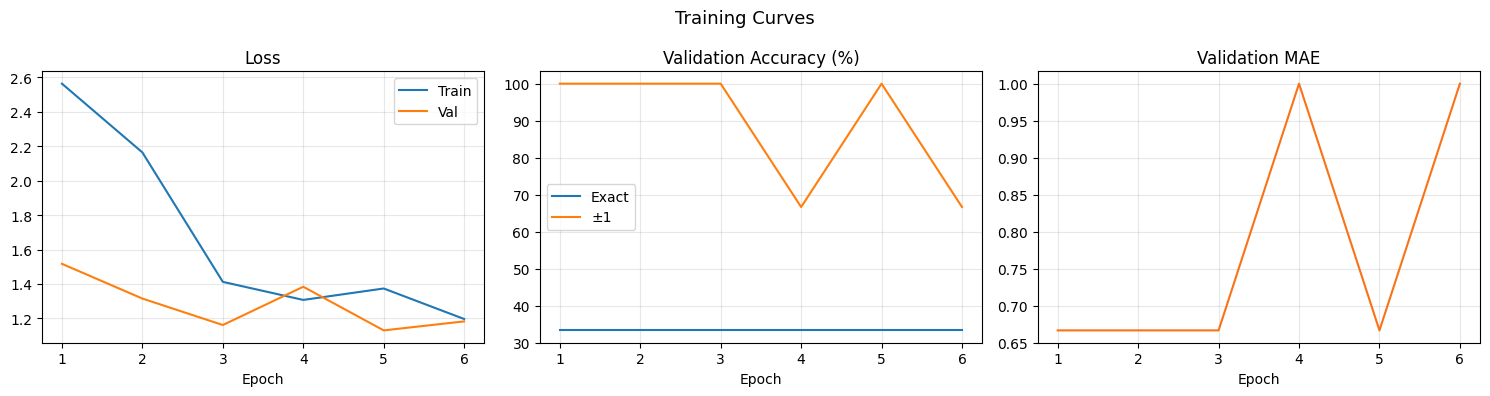

In [17]:
# ── Training curves ───────────────────────────────────────────────

if history['train_loss']:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'],   label='Val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(epochs, [v*100 for v in history['val_exact']],   label='Exact')
    axes[1].plot(epochs, [v*100 for v in history['val_within1']], label='±1')
    axes[1].set_title('Validation Accuracy (%)')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    axes[2].plot(epochs, history['val_mae'], color='#f97316')
    axes[2].set_title('Validation MAE')
    axes[2].set_xlabel('Epoch')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.suptitle('Training Curves', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No training history to plot.')

Loading best checkpoint for test evaluation...


test eval:   0%|                                                                                                                                                    | 0/1 [00:00<?, ?it/s]/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_43659/3619585571.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_MIXED_PRECISION):
                                                                                                                                                                                          


── Test Results ──────────────────────────────────────────────
  [TEST] Exact  33.3%  ±1 100.0%  MAE 0.67  HG-exact  33.3%  HG-±1 100.0%



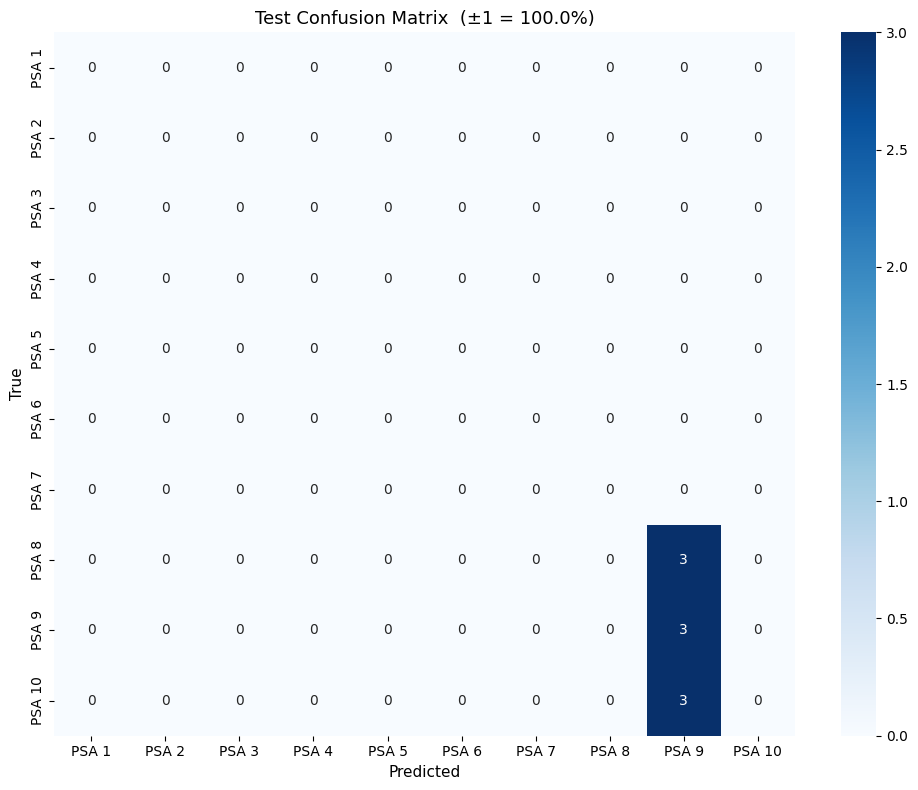

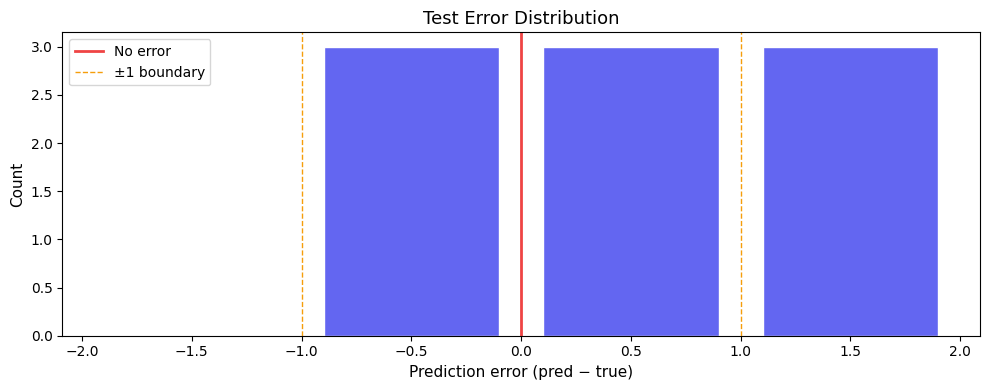


Per-grade accuracy:
  PSA  8    0.0%  
  PSA  9  100.0%  ████████████████████
  PSA 10    0.0%  


In [18]:
# ── Evaluate best model on test set ──────────────────────────────

if model is not None and test_loader is not None and best_state is not None:
    print('Loading best checkpoint for test evaluation...')
    model.load_state_dict(best_state)

    test_out = evaluate_one_epoch(model, test_loader, split='test')
    test_m   = compute_metrics(test_out['preds'], test_out['labels'])

    print('\n── Test Results ──────────────────────────────────────────────')
    print_metrics(test_m, prefix='TEST')
    print()

    plot_confusion_matrix(test_m, title=f'Test Confusion Matrix  (±1 = {test_m["within1"]*100:.1f}%)')
    plot_error_distribution(test_m, title='Test Error Distribution')

    print('\nPer-grade accuracy:')
    for g, acc in test_m['per_grade'].items():
        bar = '█' * int(acc * 20)
        print(f'  PSA {g:2d}  {acc*100:5.1f}%  {bar}')
else:
    print('Skipping test evaluation — no trained model or test data.')
    test_m = None

## 12. Error Analysis

Inspect high-confidence wrong predictions and high-grade (8/9/10) mistakes —  
both are the most costly errors in a card-grading context.

  No examples for: High-confidence correct predictions
  No examples for: High-confidence WRONG predictions


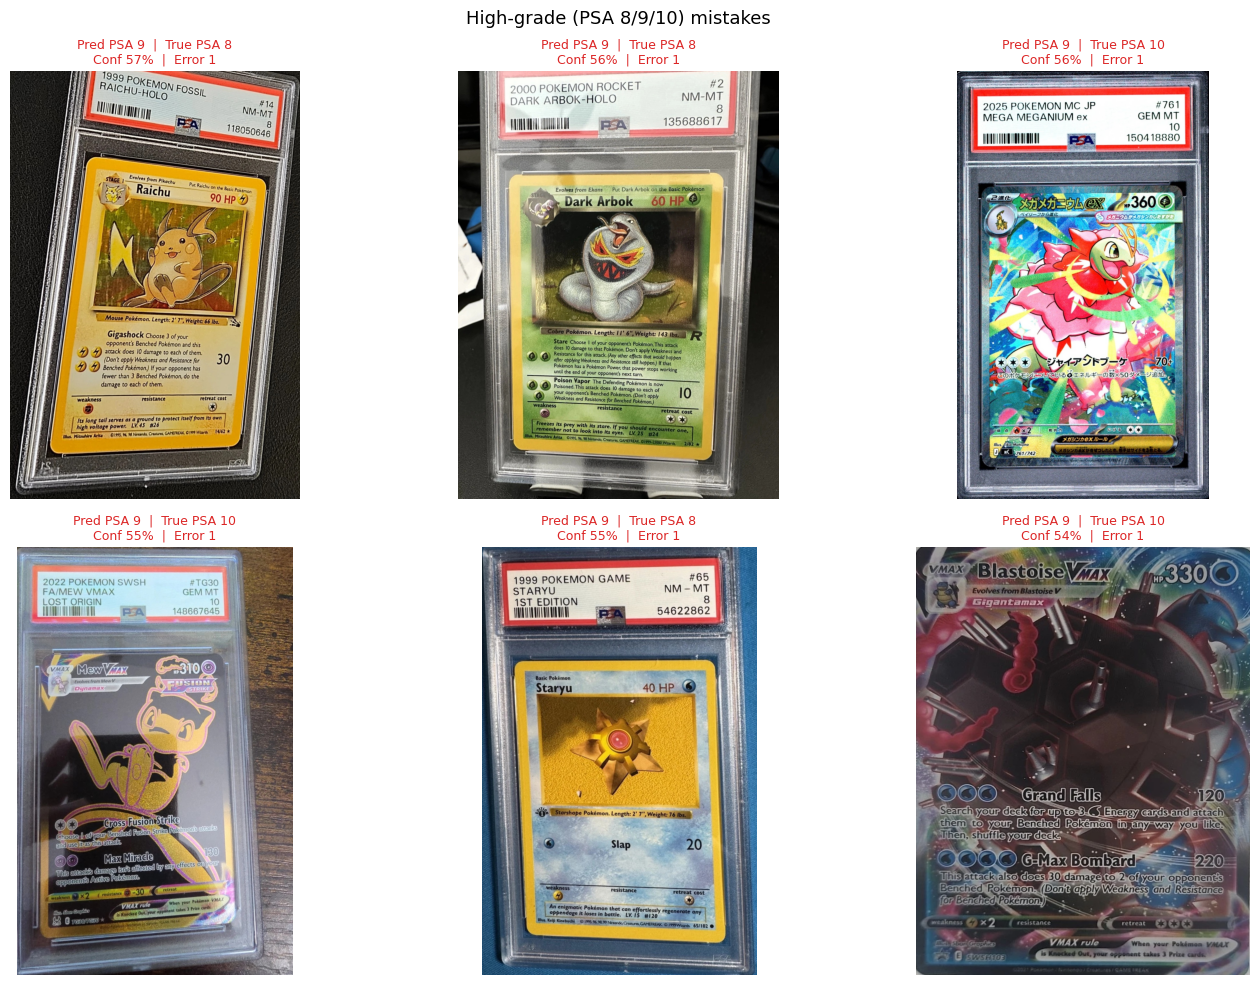

In [19]:
def show_examples(
    df:      pd.DataFrame,
    preds:   np.ndarray,
    labels:  np.ndarray,
    confs:   np.ndarray,
    title:   str,
    mask:    np.ndarray,
    n:       int = 6,
):
    """
    Visualise n examples selected by mask.
    Shows front + back images, predicted grade, true grade, confidence, error.
    """
    indices = np.where(mask)[0]
    if len(indices) == 0:
        print(f'  No examples for: {title}')
        return

    # Sort by confidence descending
    indices = indices[np.argsort(-confs[indices])][:n]

    cols = min(n, 3)
    rows = math.ceil(len(indices) / cols)
    fig  = plt.figure(figsize=(cols * 5, rows * 5))

    for plot_i, idx in enumerate(indices):
        row_data    = df.iloc[idx]
        pred_grade  = int(preds[idx])  + 1
        true_grade  = int(labels[idx]) + 1
        conf        = confs[idx]
        error       = abs(pred_grade - true_grade)

        ax = fig.add_subplot(rows, cols, plot_i + 1)

        front_img = safe_load_and_rectify(row_data.get('front_image_path'), rectify=USE_RECTIFICATION)
        if front_img is not None:
            ax.imshow(front_img)
        else:
            ax.text(0.5, 0.5, 'Image\nmissing', ha='center', va='center',
                    transform=ax.transAxes, color='gray')

        color = '#16a34a' if pred_grade == true_grade else '#dc2626'
        ax.set_title(
            f'Pred PSA {pred_grade}  |  True PSA {true_grade}\n'
            f'Conf {conf*100:.0f}%  |  Error {error}',
            fontsize=9, color=color
        )
        ax.axis('off')

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


if test_m is not None and test_loader is not None:
    preds_0  = test_out['preds']
    labels_0 = test_out['labels']
    confs    = test_out['confs']

    # 1. High-confidence correct
    show_examples(
        test_df, preds_0, labels_0, confs,
        title='High-confidence correct predictions',
        mask=(preds_0 == labels_0) & (confs > 0.8),
    )

    # 2. High-confidence wrong
    show_examples(
        test_df, preds_0, labels_0, confs,
        title='High-confidence WRONG predictions',
        mask=(preds_0 != labels_0) & (confs > 0.6),
    )

    # 3. High-grade (8/9/10) mistakes
    show_examples(
        test_df, preds_0, labels_0, confs,
        title='High-grade (PSA 8/9/10) mistakes',
        mask=(labels_0 >= 7) & (preds_0 != labels_0),
    )
else:
    print('Skipping error analysis — no test results.')

## 13. Save Artifact

In [20]:
if model is not None and best_state is not None:
    artifact = {
        'model_state_dict': best_state,
        'backbone_name':    BACKBONE_NAME,
        'img_size':         IMG_SIZE,
        'use_back_image':   USE_BACK_IMAGE,
        'target_mode':      TARGET_MODE,
        'num_classes':      NUM_CLASSES,
        'class_names':      CLASS_NAMES,
        'imagenet_mean':    list(IMAGENET_MEAN),
        'imagenet_std':     list(IMAGENET_STD),
        'metrics':          {
            k: v for k, v in (test_m or {}).items()
            if isinstance(v, (int, float, dict))
        },
        'config': {
            'seed':              SEED,
            'batch_size':        BATCH_SIZE,
            'num_epochs':        NUM_EPOCHS,
            'lr':                LR,
            'weight_decay':      WEIGHT_DECAY,
            'grad_clip':         GRAD_CLIP,
            'use_rectification': USE_RECTIFICATION,
            'use_class_weights': USE_CLASS_WEIGHTS,
        },
        'trained_at': datetime.now().isoformat(),
    }

    pt_path   = CHECKPOINT_DIR / 'grade_model_best.pt'
    json_path = CHECKPOINT_DIR / 'grade_model_best_meta.json'

    torch.save(artifact, pt_path)

    # JSON summary (no tensors)
    json_summary = {k: v for k, v in artifact.items() if k != 'model_state_dict'}
    with open(json_path, 'w') as f:
        json.dump(json_summary, f, indent=2, default=str)

    print(f'Artifact saved:')
    print(f'  {pt_path}')
    print(f'  {json_path}')
    if test_m:
        print(f'\nFinal test metrics:')
        print_metrics(test_m, prefix='TEST')

else:
    print('No model to save.')

Artifact saved:
  artifacts/finetune/grade_model_best.pt
  artifacts/finetune/grade_model_best_meta.json

Final test metrics:
  [TEST] Exact  33.3%  ±1 100.0%  MAE 0.67  HG-exact  33.3%  HG-±1 100.0%


## 14. Notes

### Notebook roles

| Notebook | Purpose |
|---|---|
| `05_feature_model.ipynb` | Frozen-feature extraction baseline (MLP on top of frozen CNN) — kept separate |
| **`06_finetune_grade_model.ipynb`** | **This notebook — end-to-end fine-tuning (recommended path)** |

### Running from scratch

1. Populate `data/pokemon_train.csv`, `data/pokemon_val.csv`, `data/pokemon_test.csv` with front/back image paths and PSA grades.
2. Set `BASEBALL_PRETRAINED_CKPT` if you have a pretrained backbone, or leave `None` to use ImageNet init.
3. Run all cells — the best checkpoint saves to `artifacts/finetune/grade_model_best.pt`.

### Planned extensions

- **Ordinal loss** — rank-aware loss (e.g. CORN, or soft label smoothing across adjacent grades) to reduce off-by-2+ errors  
- **Defect heads** — explicit branch for corner/edge/surface defect detection, supervised by PSA sub-scores  
- **Multi-crop corner branches** — crop TL/TR/BL/BR patches and fuse into the grade head  
- **Front/back-specific fusion** — separate pathways before late fusion, rather than shared backbone weights  
- **Calibration / abstention logic** — reject low-confidence predictions and route to Claude Vision fallback  
- **Pokémon-only deployment** — filter dataset by `source_dataset == 'pokemon'` for a species-specific model